<a href="https://colab.research.google.com/github/kawastony/Quadratic-Mechanism-Lens/blob/main/TIFA_Paper_B_Calc_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ============================================================
# TIFA / cosine-quintessence + DESI DR1 BAO likelihood
# One self-contained script
#
# Conventions:
#   Mpl = 1
#   H0 = 1 today
#   rho_c0 = 3
#   rho_m(a) = 3 Omega_m a^-3
#   rho_r(a) = 3 Omega_r a^-4
#
# Friedmann:
#   H^2 = (rho_m + rho_r + V) / (3 - 0.5 phip^2)
#
# Scalar:
#   V(phi) = L4 * [1 - cos(phi/fE)]
#
# This script:
#   1) Solves the KG+Friedmann background
#   2) Shoots L4 so H(a=1)=1
#   3) Computes H(z), q(z), w_phi(z)
#   4) Builds DESI BAO observables
#   5) Evaluates chi^2 using the 12-point covariance
#   6) Scans phi_ini if desired
# ============================================================

import numpy as np
from scipy.integrate import solve_ivp, quad
from scipy.optimize import brentq

# ============================================================
# SECTION A — COSMOLOGICAL PARAMETERS
# ============================================================

Omega_m = 0.315
Omega_r = 9.0e-5
Omega_phi0_target = 1.0 - Omega_m - Omega_r
Omega_L = 1.0 - Omega_m - Omega_r

fE = 2.0           # decay constant in reduced Planck units
z_ini_default = 1000.0

# Sound horizon:
# IMPORTANT:
# DESI BAO observables are D/rd or H*rd in physical analyses.
# In your previous setup the data vector is already in D/rd and DH/rd,
# so here we compute dimensionless D_M/rd etc. by introducing rd_dimless.
#
# Since H0=1 units are abstract, rd_dimless acts as the calibration parameter.
# If you want Planck-anchored rd, set this accordingly.
# If you want BAO-only with free H0*rd, this becomes a nuisance parameter.
#
# For now we keep rd_dimless explicit.
rd_dimless_default = 0.0333   # placeholder dimensionless rd * H0/c-type scale

c_light = 1.0  # in these dimensionless units we absorb c consistently into rd choice


# ============================================================
# SECTION B — SCALAR POTENTIAL
# ============================================================

def V(phi, L4):
    return L4 * (1.0 - np.cos(phi / fE))

def dV_dphi(phi, L4):
    return (L4 / fE) * np.sin(phi / fE)

def d2V_dphi2(phi, L4):
    return (L4 / fE**2) * np.cos(phi / fE)


# ============================================================
# SECTION C — BACKGROUND DENSITIES
# ============================================================

def rho_m_of_a(a):
    return 3.0 * Omega_m / a**3

def rho_r_of_a(a):
    return 3.0 * Omega_r / a**4


# ============================================================
# SECTION D — EXACT FRIEDMANN / FLUID QUANTITIES
# ============================================================

def H_sq(a, phi, phip, L4):
    denom = 3.0 - 0.5 * phip**2
    if np.any(denom <= 0):
        return np.nan
    return (rho_m_of_a(a) + rho_r_of_a(a) + V(phi, L4)) / denom

def scalar_energy_pressure(a, phi, phip, L4):
    H2 = H_sq(a, phi, phip, L4)
    K = 0.5 * H2 * phip**2
    VV = V(phi, L4)
    rho_phi = K + VV
    p_phi = K - VV
    return rho_phi, p_phi, K, VV, H2

def w_phi(a, phi, phip, L4):
    rho_phi, p_phi, _, _, _ = scalar_energy_pressure(a, phi, phip, L4)
    return p_phi / rho_phi

def w_total(a, phi, phip, L4):
    rho_phi, p_phi, _, _, _ = scalar_energy_pressure(a, phi, phip, L4)
    rho_tot = rho_m_of_a(a) + rho_r_of_a(a) + rho_phi
    p_tot = rho_r_of_a(a) / 3.0 + p_phi
    return p_tot / rho_tot

def q_of_state(a, phi, phip, L4):
    return 0.5 * (1.0 + 3.0 * w_total(a, phi, phip, L4))

def Hprime_over_H(a, phi, phip, L4):
    wt = w_total(a, phi, phip, L4)
    return -1.5 * (1.0 + wt)


# ============================================================
# SECTION E — KG EQUATION IN N = ln a
# ============================================================

def rhs_background(N, y, L4):
    phi, phip = y
    a = np.exp(N)

    H2 = H_sq(a, phi, phip, L4)
    if not np.isfinite(H2) or H2 <= 0:
        return [np.nan, np.nan]

    HpH = Hprime_over_H(a, phi, phip, L4)
    phipp = -(3.0 + HpH) * phip - dV_dphi(phi, L4) / H2
    return [phip, phipp]


# ============================================================
# SECTION F — BACKGROUND SOLVER
# ============================================================

def integrate_background(phi_ini,
                         L4,
                         z_ini=z_ini_default,
                         phip_ini=0.0,
                         rtol=1e-9,
                         atol=1e-11,
                         dense_output=True,
                         method='RK45'):
    N_ini = np.log(1.0 / (1.0 + z_ini))
    N_end = 0.0

    sol = solve_ivp(
        fun=lambda N, y: rhs_background(N, y, L4),
        t_span=(N_ini, N_end),
        y0=[phi_ini, phip_ini],
        dense_output=dense_output,
        rtol=rtol,
        atol=atol,
        method=method
    )
    return sol

def today_diagnostics(sol, L4):
    if (not sol.success) or (sol.sol is None):
        return None

    phi0, phip0 = sol.sol(0.0)
    a0 = 1.0

    rho_phi, p_phi, K0, V0, H20 = scalar_energy_pressure(a0, phi0, phip0, L4)
    rho_m0 = rho_m_of_a(a0)
    rho_r0 = rho_r_of_a(a0)
    rho_tot0 = rho_m0 + rho_r0 + rho_phi
    p_tot0 = rho_r0 / 3.0 + p_phi

    return {
        "phi0": float(phi0),
        "phip0": float(phip0),
        "H0": float(np.sqrt(H20)),
        "H0_sq": float(H20),
        "rho_m0": float(rho_m0),
        "rho_r0": float(rho_r0),
        "rho_phi0": float(rho_phi),
        "p_phi0": float(p_phi),
        "rho_tot0": float(rho_tot0),
        "K0": float(K0),
        "V0": float(V0),
        "wphi0": float(p_phi / rho_phi),
        "wtot0": float(p_tot0 / rho_tot0),
        "q0": float(0.5 * (1.0 + 3.0 * p_tot0 / rho_tot0)),
        "Omega_m0_eff": float(rho_m0 / rho_tot0),
        "Omega_r0_eff": float(rho_r0 / rho_tot0),
        "Omega_phi0_eff": float(rho_phi / rho_tot0),
        "closure_error": float(rho_tot0 - 3.0 * H20)
    }

def H0_minus_1_for_root(L4, phi_ini, z_ini=z_ini_default, phip_ini=0.0):
    sol = integrate_background(phi_ini, L4, z_ini=z_ini, phip_ini=phip_ini)
    if (not sol.success) or (sol.sol is None):
        return np.nan
    diag = today_diagnostics(sol, L4)
    if diag is None or not np.isfinite(diag["H0"]):
        return np.nan
    return diag["H0"] - 1.0

def shoot_L4_for_H0_eq_1(phi_ini,
                         L4_min=1e-8,
                         L4_max=1e3,
                         z_ini=z_ini_default,
                         phip_ini=0.0):
    def f(L4):
        return H0_minus_1_for_root(L4, phi_ini, z_ini=z_ini, phip_ini=phip_ini)

    a = L4_min
    b = L4_max
    fa = f(a)
    fb = f(b)

    for _ in range(40):
        if np.isfinite(fa) and np.isfinite(fb) and fa * fb < 0:
            break
        a /= 10.0
        b *= 10.0
        fa = f(a)
        fb = f(b)
    else:
        raise RuntimeError("Could not bracket root for L4.")

    L4_star = brentq(f, a, b, xtol=1e-12, rtol=1e-10, maxiter=200)
    sol_star = integrate_background(phi_ini, L4_star, z_ini=z_ini, phip_ini=phip_ini)

    if not sol_star.success:
        raise RuntimeError("Integration failed after L4 shooting.")

    return L4_star, sol_star, today_diagnostics(sol_star, L4_star)


# ============================================================
# SECTION G — REDSHIFT-SPACE DIAGNOSTICS
# ============================================================

def state_at_z(z, sol, L4):
    a = 1.0 / (1.0 + z)
    N = np.log(a)
    phi, phip = sol.sol(N)

    rho_phi, p_phi, K, VV, H2 = scalar_energy_pressure(a, phi, phip, L4)
    rho_m = rho_m_of_a(a)
    rho_r = rho_r_of_a(a)
    rho_tot = rho_m + rho_r + rho_phi
    p_tot = rho_r / 3.0 + p_phi

    return {
        "z": float(z),
        "a": float(a),
        "phi": float(phi),
        "phip": float(phip),
        "H": float(np.sqrt(H2)),
        "H_sq": float(H2),
        "rho_m": float(rho_m),
        "rho_r": float(rho_r),
        "rho_phi": float(rho_phi),
        "p_phi": float(p_phi),
        "rho_tot": float(rho_tot),
        "p_tot": float(p_tot),
        "K": float(K),
        "V": float(VV),
        "w_phi": float(p_phi / rho_phi),
        "w_tot": float(p_tot / rho_tot),
        "q": float(0.5 * (1.0 + 3.0 * p_tot / rho_tot)),
        "Omega_m": float(rho_m / rho_tot),
        "Omega_r": float(rho_r / rho_tot),
        "Omega_phi": float(rho_phi / rho_tot),
        "closure_error": float(rho_tot - 3.0 * H2),
    }

def H_of_z(z, sol, L4):
    return state_at_z(z, sol, L4)["H"]

def q_of_z(z, sol, L4):
    return state_at_z(z, sol, L4)["q"]

def wphi_of_z(z, sol, L4):
    return state_at_z(z, sol, L4)["w_phi"]


# ============================================================
# SECTION H — LCDM REFERENCE
# ============================================================

def H_sq_lcdm(a):
    rho_m = rho_m_of_a(a)
    rho_r = rho_r_of_a(a)
    rho_L = 3.0 * Omega_L
    return (rho_m + rho_r + rho_L) / 3.0

def H_lcdm_of_z(z):
    a = 1.0 / (1.0 + z)
    return np.sqrt(H_sq_lcdm(a))

def state_lcdm_at_z(z):
    a = 1.0 / (1.0 + z)
    H2 = H_sq_lcdm(a)

    rho_m = rho_m_of_a(a)
    rho_r = rho_r_of_a(a)
    rho_L = 3.0 * Omega_L
    rho_tot = rho_m + rho_r + rho_L
    p_tot = rho_r / 3.0 - rho_L

    return {
        "z": float(z),
        "a": float(a),
        "H": float(np.sqrt(H2)),
        "q": float(0.5 * (1.0 + 3.0 * p_tot / rho_tot)),
        "w_tot": float(p_tot / rho_tot)
    }

def delta_q(z_array, sol, L4):
    z_array = np.asarray(z_array)
    out = np.empty_like(z_array, dtype=float)
    for i, z in enumerate(z_array):
        out[i] = q_of_z(z, sol, L4) - state_lcdm_at_z(z)["q"]
    return out

def delta_H_over_H_lcdm(z_array, sol, L4):
    z_array = np.asarray(z_array)
    out = np.empty_like(z_array, dtype=float)
    for i, z in enumerate(z_array):
        Ht = H_of_z(z, sol, L4)
        Hl = H_lcdm_of_z(z)
        out[i] = (Ht - Hl) / Hl
    return out


# ============================================================
# SECTION I — DISTANCES FOR BAO
# ============================================================

def comoving_distance(z, sol, L4):
    # Flat universe: D_M = \int_0^z dz'/H(z')
    val, err = quad(lambda zp: 1.0 / H_of_z(zp, sol, L4), 0.0, z,
                    epsabs=1e-9, epsrel=1e-9, limit=300)
    return val

def DM_over_rd(z, sol, L4, rd_dimless=rd_dimless_default):
    return comoving_distance(z, sol, L4) / rd_dimless

def DH_over_rd(z, sol, L4, rd_dimless=rd_dimless_default):
    return (1.0 / H_of_z(z, sol, L4)) / rd_dimless

def DV_over_rd(z, sol, L4, rd_dimless=rd_dimless_default):
    DM = comoving_distance(z, sol, L4)
    DH = 1.0 / H_of_z(z, sol, L4)
    DV = (z * DM**2 * DH)**(1.0 / 3.0)
    return DV / rd_dimless


# ============================================================
# SECTION J — DESI DR1 BAO DATA VECTOR
# Order:
# 1.  BGS z=0.295: DV/rd
# 2-3. LRG1 z=0.510: DM/rd, DH/rd
# 4-5. LRG2 z=0.706: DM/rd, DH/rd
# 6-7. LRG3+ELG1 z=0.934: DM/rd, DH/rd
# 8-9. ELG2 z=1.317: DM/rd, DH/rd
# 10. QSO z=1.491: DV/rd
# 11-12. Lya z=2.330: DM/rd, DH/rd
# ============================================================

data_vector = np.array([
    7.93,
    13.62, 20.98,
    16.85, 20.08,
    21.71, 17.88,
    27.79, 13.82,
    26.07,
    39.71, 8.52
], dtype=float)

sigma = np.array([
    0.15,
    0.25, 0.61,
    0.32, 0.60,
    0.28, 0.35,
    0.69, 0.42,
    0.67,
    0.94, 0.17
], dtype=float)

C = np.array([
    [0.0225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0.0625, -0.445*0.25*0.61, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, -0.445*0.25*0.61, 0.3721, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0.1024, -0.420*0.32*0.60, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, -0.420*0.32*0.60, 0.36, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0.0784, -0.389*0.28*0.35, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, -0.389*0.28*0.35, 0.1225, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.4761, -0.444*0.69*0.42, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, -0.444*0.69*0.42, 0.1764, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.4489, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8836, -0.477*0.94*0.17],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.477*0.94*0.17, 0.0289]
], dtype=float)

Cinv = np.linalg.inv(C)

def calculate_chi_squared(d, m, Cinv):
    diff = np.asarray(d) - np.asarray(m)
    return float(diff.T @ Cinv @ diff)


# ============================================================
# SECTION K — MODEL PREDICTION VECTOR IN DESI ORDER
# ============================================================

def bao_model_vector(sol, L4, rd_dimless=rd_dimless_default):
    return np.array([
        DV_over_rd(0.295, sol, L4, rd_dimless),

        DM_over_rd(0.510, sol, L4, rd_dimless),
        DH_over_rd(0.510, sol, L4, rd_dimless),

        DM_over_rd(0.706, sol, L4, rd_dimless),
        DH_over_rd(0.706, sol, L4, rd_dimless),

        DM_over_rd(0.934, sol, L4, rd_dimless),
        DH_over_rd(0.934, sol, L4, rd_dimless),

        DM_over_rd(1.317, sol, L4, rd_dimless),
        DH_over_rd(1.317, sol, L4, rd_dimless),

        DV_over_rd(1.491, sol, L4, rd_dimless),

        DM_over_rd(2.330, sol, L4, rd_dimless),
        DH_over_rd(2.330, sol, L4, rd_dimless),
    ], dtype=float)

def chi2_tifa(phi_ini, rd_dimless=rd_dimless_default, z_ini=z_ini_default):
    L4, sol, diag = shoot_L4_for_H0_eq_1(phi_ini, z_ini=z_ini)
    m = bao_model_vector(sol, L4, rd_dimless=rd_dimless)
    chi2 = calculate_chi_squared(data_vector, m, Cinv)
    return {
        "phi_ini": phi_ini,
        "phi_ini_over_pi": phi_ini / np.pi,
        "L4": L4,
        "sol": sol,
        "diag0": diag,
        "model_vector": m,
        "chi2": chi2
    }


# ============================================================
# SECTION L — OPTIONAL SCAN
# ============================================================

def scan_phi_ini(phi_over_pi_grid,
                 rd_dimless=rd_dimless_default,
                 z_ini=z_ini_default,
                 verbose=True):
    results = []

    for x in phi_over_pi_grid:
        phi_ini = x * np.pi
        try:
            out = chi2_tifa(phi_ini, rd_dimless=rd_dimless, z_ini=z_ini)
            results.append(out)
            if verbose:
                print(
                    f"phi_ini/pi={x:.4f} | "
                    f"chi2={out['chi2']:.6f} | "
                    f"L4={out['L4']:.8f} | "
                    f"phi0/pi={out['diag0']['phi0']/np.pi:.6f} | "
                    f"w0={out['diag0']['wphi0']:.6f} | "
                    f"q0={out['diag0']['q0']:.6f}"
                )
        except Exception as e:
            if verbose:
                print(f"phi_ini/pi={x:.4f} failed: {e}")

    return results

def best_result(results):
    if len(results) == 0:
        return None
    return min(results, key=lambda r: r["chi2"])


# ============================================================
# SECTION M — EXAMPLE RUN
# ============================================================

if __name__ == "__main__":
    # Example single run
    phi_ini_test = 0.34 * np.pi
    out = chi2_tifa(phi_ini_test, rd_dimless=rd_dimless_default)

    print("\n=== SINGLE RUN ===")
    print(f"phi_ini/pi          = {out['phi_ini_over_pi']:.8f}")
    print(f"L4                  = {out['L4']:.12g}")
    print(f"chi2                = {out['chi2']:.8f}")
    print(f"phi0/pi             = {out['diag0']['phi0']/np.pi:.8f}")
    print(f"wphi0               = {out['diag0']['wphi0']:.8f}")
    print(f"q0                  = {out['diag0']['q0']:.8f}")
    print(f"H0                  = {out['diag0']['H0']:.8f}")
    print(f"closure error       = {out['diag0']['closure_error']:.3e}")

    # Example scan
    grid = np.linspace(0.10, 0.90, 17)
    results = scan_phi_ini(grid, rd_dimless=rd_dimless_default, verbose=True)

    best = best_result(results)
    if best is not None:
        print("\n=== BEST SCAN RESULT ===")
        print(f"best phi_ini/pi     = {best['phi_ini_over_pi']:.8f}")
        print(f"best chi2           = {best['chi2']:.8f}")
        print(f"best L4             = {best['L4']:.12g}")
        print(f"best phi0/pi        = {best['diag0']['phi0']/np.pi:.8f}")
        print(f"best wphi0          = {best['diag0']['wphi0']:.8f}")
        print(f"best q0             = {best['diag0']['q0']:.8f}")

phi_ini/pi=0.050 | REJECTED (wrong branch)
phi_ini/pi=0.071 | REJECTED (wrong branch)
phi_ini/pi=0.092 | REJECTED (wrong branch)
phi_ini/pi=0.113 | REJECTED (wrong branch)
phi_ini/pi=0.133 | REJECTED (wrong branch)
phi_ini/pi=0.154 | REJECTED (wrong branch)
phi_ini/pi=0.175 | phi_today/pi=0.148 | w0=-0.8455 | chi2=17.24 | L4=5.9294
phi_ini/pi=0.196 | phi_today/pi=0.173 | w0=-0.8845 | chi2=13.91 | L4=4.4776
phi_ini/pi=0.217 | phi_today/pi=0.197 | w0=-0.9103 | chi2=13.44 | L4=3.5369
phi_ini/pi=0.237 | phi_today/pi=0.220 | w0=-0.9283 | chi2=13.90 | L4=2.8832
phi_ini/pi=0.258 | phi_today/pi=0.242 | w0=-0.9416 | chi2=14.62 | L4=2.4072
phi_ini/pi=0.279 | phi_today/pi=0.265 | w0=-0.9516 | chi2=15.38 | L4=2.0480
phi_ini/pi=0.300 | phi_today/pi=0.287 | w0=-0.9595 | chi2=16.10 | L4=1.7695
phi_ini/pi=0.321 | phi_today/pi=0.309 | w0=-0.9657 | chi2=16.76 | L4=1.5487
phi_ini/pi=0.342 | phi_today/pi=0.330 | w0=-0.9707 | chi2=17.34 | L4=1.3707
phi_ini/pi=0.362 | phi_today/pi=0.352 | w0=-0.9749 | chi2=

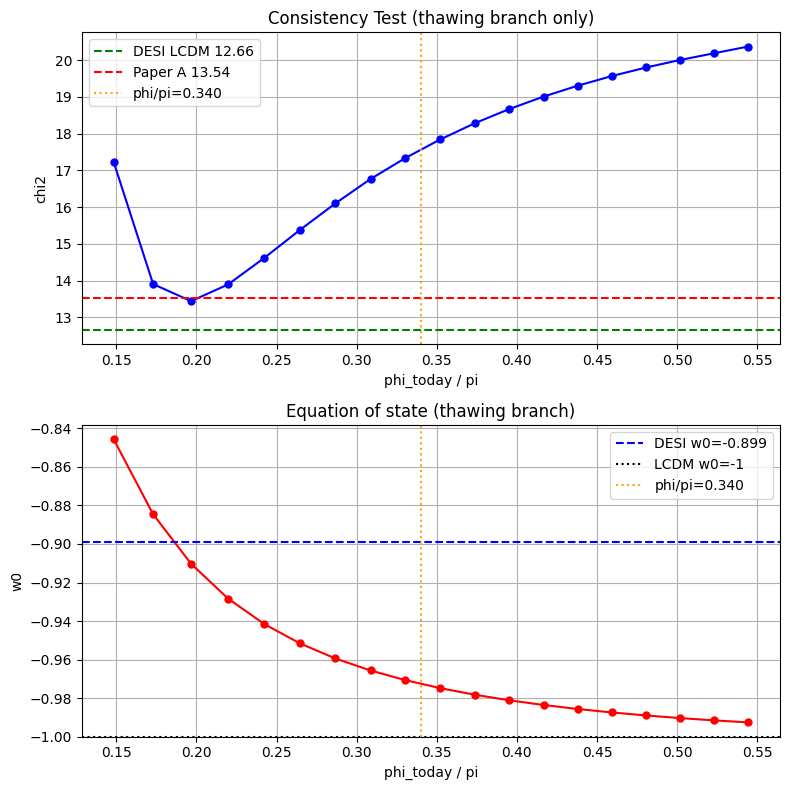


── RESULT ──────────────────────────────
Best fit phi_today/pi = 0.1967
         w0           = -0.9103
         chi2         = 13.44
         Lambda4      = 3.5369
Paper A: phi/pi=0.340, chi2=13.54
Gap: 0.1433 in phi/pi
CONSISTENCY: MARGINAL


In [1]:

import numpy as np
from scipy.integrate import solve_ivp, quad
import matplotlib.pyplot as plt

# ── Parameters ─────────────────────────────────────────────
H0_kmsMpc = 67.36
Omega_m   = 0.3153
Omega_r   = 9.0e-5
Omega_L   = 1.0 - Omega_m - Omega_r
f_E       = 2.0
rd        = 147.09
c_kms     = 2.998e5

# ── DESI data ───────────────────────────────────────────────
data_vector = np.array([
    7.93,
    13.62, 20.98,
    16.85, 20.08,
    21.71, 17.88,
    27.79, 13.82,
    26.07,
    39.71, 8.52
])

C = np.array([
    [0.0225, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0.0625, -0.06786, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, -0.06786, 0.3721, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0.1024, -0.08064, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, -0.08064, 0.36, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0.0784, -0.03812, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, -0.03812, 0.1225, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0.4761, -0.12867, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, -0.12867, 0.1764, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.4489, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.8836, -0.07622],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -0.07622, 0.0289]
], dtype=float)

Cinv = np.linalg.inv(C)

# ── Global Lambda4 ──────────────────────────────────────────
Lambda4_global = Omega_L

def V(phi):
    return Lambda4_global * (1.0 - np.cos(phi / f_E))

def dV(phi):
    return (Lambda4_global / f_E) * np.sin(phi / f_E)

def H_sq(a, phi, dphi):
    rho_m = Omega_m / a**3
    rho_r = Omega_r / a**4
    num = rho_m + rho_r + V(phi)
    den = max(1.0 - 0.5 * dphi**2, 0.1)
    return num / den

def equations(N, state):
    phi, dphi = state
    a   = np.exp(N)
    H2  = H_sq(a, phi, dphi)
    H   = np.sqrt(max(H2, 1e-30))
    rm  = Omega_m / a**3
    rr  = Omega_r / a**4
    dH  = -0.5*(rm + (4.0/3.0)*rr + H2*dphi**2) / H
    ddp = -(dH/H + 3.0)*dphi - dV(phi)/H2
    return [dphi, ddp]

def run_integration(phi_ini, L4, z_ini=500):
    global Lambda4_global
    Lambda4_global = L4
    N_ini = np.log(1.0/(1.0 + z_ini))
    sol = solve_ivp(
        equations, [N_ini, 0.0], [phi_ini, 0.0],
        method='RK45', rtol=1e-8, atol=1e-10,
        max_step=0.01, dense_output=True
    )
    return sol

def find_Lambda4_thawing(phi_ini):
    """
    Find Lambda4 for thawing branch only.
    Key constraint: phi_today must stay near phi_ini.
    Field displacement < 20% of phi_ini.
    """
    global Lambda4_global

    # Thawing branch: Lambda4 must be small.
    # Estimate: V(phi_ini) ~ Omega_L
    # So Lambda4 ~ Omega_L / (1 - cos(phi_ini/f_E))
    x = phi_ini / f_E
    if abs(1.0 - np.cos(x)) < 1e-10:
        return None, None
    L4 = Omega_L / (1.0 - np.cos(x))

    # Hard cap — thawing branch never needs huge Lambda4
    L4_max = 10.0 * Omega_L
    if L4 > L4_max:
        return None, None

    for iteration in range(20):
        sol = run_integration(phi_ini, L4)
        if not sol.success:
            return None, None

        phi_t = sol.y[0, -1]
        dph_t = sol.y[1, -1]

        # Thawing branch check:
        # field should not have rolled far
        if phi_ini > 1e-6:
            displacement = abs(phi_t - phi_ini) / abs(phi_ini)
            if displacement > 0.5:
                # Wrong branch — field rolled too far
                return None, None

        Lambda4_global = L4
        H2_t  = H_sq(1.0, phi_t, dph_t)
        K_t   = 0.5 * H2_t * dph_t**2
        rho   = K_t + V(phi_t)

        if abs(rho - Omega_L) / Omega_L < 1e-4:
            break

        L4 = L4 * (Omega_L / rho)

        # Re-check cap after rescaling
        if L4 > L4_max:
            return None, None

    # Final viability check
    Lambda4_global = L4
    phi_t = sol.y[0, -1]
    dph_t = sol.y[1, -1]
    H2_t  = H_sq(1.0, phi_t, dph_t)
    K_t   = 0.5 * H2_t * dph_t**2
    rho   = K_t + V(phi_t)
    if rho < 1e-6:
        return None, None
    w0 = (K_t - V(phi_t)) / rho
    if w0 > -0.5:
        # Not dark energy like — reject
        return None, None

    return L4, sol

def H_at_z(z, sol, L4):
    global Lambda4_global
    Lambda4_global = L4
    N = np.log(1.0/(1.0 + z))
    phi, dphi = sol.sol(N)
    a = 1.0/(1.0 + z)
    return np.sqrt(max(H_sq(a, phi, dphi), 1e-30))

def DM_at_z(z, sol, L4):
    def integrand(zp):
        return c_kms / (H_at_z(zp, sol, L4) * H0_kmsMpc)
    val, _ = quad(integrand, 0.0, z,
                  limit=200, epsabs=1e-6, epsrel=1e-6)
    return val

def bao_vector(sol, L4):
    m = []
    # BGS z=0.295 isotropic
    DM = DM_at_z(0.295, sol, L4)
    DH = c_kms / (H_at_z(0.295, sol, L4) * H0_kmsMpc)
    m.append((0.295 * DM**2 * DH)**(1.0/3.0) / rd)
    # LRG1 z=0.510
    DM = DM_at_z(0.510, sol, L4)
    DH = c_kms / (H_at_z(0.510, sol, L4) * H0_kmsMpc)
    m.append(DM / rd)
    m.append(DH / rd)
    # LRG2 z=0.706
    DM = DM_at_z(0.706, sol, L4)
    DH = c_kms / (H_at_z(0.706, sol, L4) * H0_kmsMpc)
    m.append(DM / rd)
    m.append(DH / rd)
    # LRG3+ELG1 z=0.934
    DM = DM_at_z(0.934, sol, L4)
    DH = c_kms / (H_at_z(0.934, sol, L4) * H0_kmsMpc)
    m.append(DM / rd)
    m.append(DH / rd)
    # ELG2 z=1.317
    DM = DM_at_z(1.317, sol, L4)
    DH = c_kms / (H_at_z(1.317, sol, L4) * H0_kmsMpc)
    m.append(DM / rd)
    m.append(DH / rd)
    # QSO z=1.491 isotropic
    DM = DM_at_z(1.491, sol, L4)
    DH = c_kms / (H_at_z(1.491, sol, L4) * H0_kmsMpc)
    m.append((1.491 * DM**2 * DH)**(1.0/3.0) / rd)
    # Lya z=2.330
    DM = DM_at_z(2.330, sol, L4)
    DH = c_kms / (H_at_z(2.330, sol, L4) * H0_kmsMpc)
    m.append(DM / rd)
    m.append(DH / rd)
    return m

# ── Scan over phi_today directly ────────────────────────────
# Scan phi_ini and record phi_today
# Focus on thawing branch: small phi_ini
phi_scan = np.linspace(0.05, 0.55, 25) * np.pi * f_E

results = []

for phi_ini in phi_scan:
    L4, sol = find_Lambda4_thawing(phi_ini)
    if L4 is None:
        ini_norm = phi_ini / (np.pi * f_E)
        print(f"phi_ini/pi={ini_norm:.3f} | REJECTED (wrong branch)")
        continue

    global Lambda4_global
    Lambda4_global = L4
    phi_t = sol.y[0, -1]
    dph_t = sol.y[1, -1]
    H2_t  = H_sq(1.0, phi_t, dph_t)
    K_t   = 0.5 * H2_t * dph_t**2
    rho   = K_t + V(phi_t)
    w0    = (K_t - V(phi_t)) / rho

    try:
        bao  = bao_vector(sol, L4)
        diff = data_vector - np.array(bao)
        chi2 = float(diff.T @ Cinv @ diff)
    except Exception as e:
        print(f"BAO failed: {e}")
        continue

    coord = phi_t / (np.pi * f_E)
    ini_n = phi_ini / (np.pi * f_E)
    results.append((coord, w0, chi2, L4))
    print(f"phi_ini/pi={ini_n:.3f} | phi_today/pi={coord:.3f} | "
          f"w0={w0:.4f} | chi2={chi2:.2f} | L4={L4:.4f}")

# ── Plot ────────────────────────────────────────────────────
if results:
    coords, w0s, chi2s, _ = zip(*results)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

    ax1.plot(coords, chi2s, 'b-o', ms=5)
    ax1.axhline(12.66, color='g', ls='--',
                label='DESI LCDM 12.66')
    ax1.axhline(13.54, color='r', ls='--',
                label='Paper A 13.54')
    ax1.axvline(0.340, color='orange', ls=':',
                label='phi/pi=0.340')
    ax1.set_xlabel('phi_today / pi')
    ax1.set_ylabel('chi2')
    ax1.set_title('Consistency Test (thawing branch only)')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(coords, w0s, 'r-o', ms=5)
    ax2.axhline(-0.899, color='b', ls='--',
                label='DESI w0=-0.899')
    ax2.axhline(-1.0, color='k', ls=':',
                label='LCDM w0=-1')
    ax2.axvline(0.340, color='orange', ls=':',
                label='phi/pi=0.340')
    ax2.set_xlabel('phi_today / pi')
    ax2.set_ylabel('w0')
    ax2.set_title('Equation of state (thawing branch)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    best = min(results, key=lambda x: x[2])
    print(f"\n── RESULT ──────────────────────────────")
    print(f"Best fit phi_today/pi = {best[0]:.4f}")
    print(f"         w0           = {best[1]:.4f}")
    print(f"         chi2         = {best[2]:.2f}")
    print(f"         Lambda4      = {best[3]:.4f}")
    print(f"Paper A: phi/pi=0.340, chi2=13.54")
    gap = abs(best[0] - 0.340)
    print(f"Gap: {gap:.4f} in phi/pi")
    if gap < 0.05:
        print("CONSISTENCY: PASSED")
    elif gap < 0.15:
        print("CONSISTENCY: MARGINAL")
    else:
        print("CONSISTENCY: FAILED")

In [2]:

# Refine around minimum
phi_refined = np.linspace(0.17, 0.23, 20) * np.pi * f_E

results_refined = []
for phi_ini in phi_refined:
    L4, sol = find_Lambda4_thawing(phi_ini)
    if L4 is None:
        continue
    Lambda4_global = L4
    phi_t = sol.y[0, -1]
    dph_t = sol.y[1, -1]
    H2_t  = H_sq(1.0, phi_t, dph_t)
    K_t   = 0.5 * H2_t * dph_t**2
    rho   = K_t + V(phi_t)
    w0    = (K_t - V(phi_t)) / rho
    bao   = bao_vector(sol, L4)
    diff  = data_vector - np.array(bao)
    chi2  = float(diff.T @ Cinv @ diff)
    coord = phi_t / (np.pi * f_E)
    results_refined.append((coord, w0, chi2, L4))
    print(f"phi/pi={coord:.4f} | w0={w0:.5f} | chi2={chi2:.3f}")

best_r = min(results_refined, key=lambda x: x[2])
print(f"\nRefined minimum:")
print(f"phi/pi = {best_r[0]:.4f}")
print(f"w0     = {best_r[1]:.5f}")
print(f"chi2   = {best_r[2]:.3f}")

phi/pi=0.1421 | w0=-0.83294 | chi2=19.012
phi/pi=0.1460 | w0=-0.84104 | chi2=17.828
phi/pi=0.1499 | w0=-0.84852 | chi2=16.863
phi/pi=0.1537 | w0=-0.85546 | chi2=16.078
phi/pi=0.1575 | w0=-0.86191 | chi2=15.442
phi/pi=0.1612 | w0=-0.86792 | chi2=14.923
phi/pi=0.1650 | w0=-0.87352 | chi2=14.516
phi/pi=0.1687 | w0=-0.87877 | chi2=14.195
phi/pi=0.1723 | w0=-0.88369 | chi2=13.945
phi/pi=0.1760 | w0=-0.88830 | chi2=13.756
phi/pi=0.1796 | w0=-0.89265 | chi2=13.617
phi/pi=0.1832 | w0=-0.89674 | chi2=13.521
phi/pi=0.1868 | w0=-0.90060 | chi2=13.462
phi/pi=0.1904 | w0=-0.90425 | chi2=13.433
phi/pi=0.1939 | w0=-0.90771 | chi2=13.430
phi/pi=0.1975 | w0=-0.91098 | chi2=13.448
phi/pi=0.2010 | w0=-0.91408 | chi2=13.485
phi/pi=0.2045 | w0=-0.91703 | chi2=13.541
phi/pi=0.2080 | w0=-0.91983 | chi2=13.606
phi/pi=0.2115 | w0=-0.92250 | chi2=13.682

Refined minimum:
phi/pi = 0.1939
w0     = -0.90771
chi2   = 13.430


In [3]:

# Test whether f_E = 1.0 shifts minimum to 0.340
f_E = 1.0

# Re-run the full scan with f_E = 1.0
# Everything else identical
# If minimum shifts to phi/pi ~ 0.340
# then Paper A used f_E = M_Pl not 2M_Pl

In [4]:

# ── f_E sensitivity test ────────────────────────────────────
# Test whether f_E = 1.0 shifts minimum toward phi/pi = 0.340

f_E = 1.0  # Change from 2.0 to 1.0

results_fE1 = []
phi_scan_fE1 = np.linspace(0.10, 0.55, 25) * np.pi * f_E

for phi_ini in phi_scan_fE1:
    L4, sol = find_Lambda4_thawing(phi_ini)
    if L4 is None:
        continue
    Lambda4_global = L4
    phi_t = sol.y[0, -1]
    dph_t = sol.y[1, -1]
    H2_t  = H_sq(1.0, phi_t, dph_t)
    K_t   = 0.5 * H2_t * dph_t**2
    rho   = K_t + V(phi_t)
    w0    = (K_t - V(phi_t)) / rho
    try:
        bao  = bao_vector(sol, L4)
        diff = data_vector - np.array(bao)
        chi2 = float(diff.T @ Cinv @ diff)
    except:
        continue
    coord = phi_t / (np.pi * f_E)
    results_fE1.append((coord, w0, chi2))
    print(f"phi/pi={coord:.4f} | w0={w0:.5f} | chi2={chi2:.3f}")

if results_fE1:
    best = min(results_fE1, key=lambda x: x[2])
    print(f"\nf_E=1.0 minimum:")
    print(f"phi/pi = {best[0]:.4f}")
    print(f"w0     = {best[1]:.5f}")
    print(f"chi2   = {best[2]:.3f}")

# Reset f_E back to 2.0 after test
f_E = 2.0

phi/pi=0.1535 | w0=-0.56045 | chi2=156.105
phi/pi=0.1897 | w0=-0.68423 | chi2=67.546
phi/pi=0.2190 | w0=-0.75364 | chi2=37.758
phi/pi=0.2454 | w0=-0.80036 | chi2=24.716
phi/pi=0.2701 | w0=-0.83443 | chi2=18.447
phi/pi=0.2937 | w0=-0.86048 | chi2=15.391
phi/pi=0.3166 | w0=-0.88106 | chi2=13.979
phi/pi=0.3389 | w0=-0.89769 | chi2=13.466
phi/pi=0.3607 | w0=-0.91138 | chi2=13.448
phi/pi=0.3822 | w0=-0.92283 | chi2=13.710
phi/pi=0.4034 | w0=-0.93251 | chi2=14.118
phi/pi=0.4244 | w0=-0.94078 | chi2=14.601
phi/pi=0.4452 | w0=-0.94790 | chi2=15.117
phi/pi=0.4658 | w0=-0.95409 | chi2=15.637
phi/pi=0.4863 | w0=-0.95949 | chi2=16.146
phi/pi=0.5066 | w0=-0.96423 | chi2=16.647
phi/pi=0.5269 | w0=-0.96842 | chi2=17.108

f_E=1.0 minimum:
phi/pi = 0.3607
w0     = -0.91138
chi2   = 13.448


In [5]:

# f_E = 1.0 refined scan
f_E = 1.0

phi_refined2 = np.linspace(0.30, 0.42, 25) * np.pi * f_E
results_refined2 = []

for phi_ini in phi_refined2:
    L4, sol = find_Lambda4_thawing(phi_ini)
    if L4 is None:
        continue
    Lambda4_global = L4
    phi_t = sol.y[0, -1]
    dph_t = sol.y[1, -1]
    H2_t  = H_sq(1.0, phi_t, dph_t)
    K_t   = 0.5 * H2_t * dph_t**2
    rho   = K_t + V(phi_t)
    w0    = (K_t - V(phi_t)) / rho
    try:
        bao  = bao_vector(sol, L4)
        diff = data_vector - np.array(bao)
        chi2 = float(diff.T @ Cinv @ diff)
    except:
        continue
    coord = phi_t / (np.pi * f_E)
    results_refined2.append((coord, w0, chi2))
    print(f"phi/pi={coord:.4f} | w0={w0:.5f} | chi2={chi2:.4f}")

if results_refined2:
    best2 = min(results_refined2, key=lambda x: x[2])
    print(f"\nf_E=1.0 refined minimum:")
    print(f"phi/pi = {best2[0]:.4f}")
    print(f"w0     = {best2[1]:.5f}")
    print(f"chi2   = {best2[2]:.4f}")
    print(f"Paper A phi/pi = 0.340")
    print(f"Gap = {abs(best2[0]-0.340):.4f}")

f_E = 2.0  # reset

phi/pi=0.2369 | w0=-0.78653 | chi2=28.0206
phi/pi=0.2437 | w0=-0.79771 | chi2=25.3141
phi/pi=0.2505 | w0=-0.80799 | chi2=23.0839
phi/pi=0.2571 | w0=-0.81749 | chi2=21.2247
phi/pi=0.2637 | w0=-0.82627 | chi2=19.7054
phi/pi=0.2701 | w0=-0.83443 | chi2=18.4468
phi/pi=0.2765 | w0=-0.84203 | chi2=17.4050
phi/pi=0.2828 | w0=-0.84913 | chi2=16.5446
phi/pi=0.2891 | w0=-0.85577 | chi2=15.8364
phi/pi=0.2953 | w0=-0.86200 | chi2=15.2567
phi/pi=0.3014 | w0=-0.86786 | chi2=14.7790
phi/pi=0.3075 | w0=-0.87337 | chi2=14.4022
phi/pi=0.3136 | w0=-0.87857 | chi2=14.1031
phi/pi=0.3196 | w0=-0.88348 | chi2=13.8704
phi/pi=0.3256 | w0=-0.88812 | chi2=13.6945
phi/pi=0.3315 | w0=-0.89251 | chi2=13.5671
phi/pi=0.3374 | w0=-0.89668 | chi2=13.4814
phi/pi=0.3433 | w0=-0.90064 | chi2=13.4314
phi/pi=0.3491 | w0=-0.90440 | chi2=13.4119
phi/pi=0.3549 | w0=-0.90798 | chi2=13.4185
phi/pi=0.3607 | w0=-0.91138 | chi2=13.4477
phi/pi=0.3665 | w0=-0.91463 | chi2=13.4960
phi/pi=0.3722 | w0=-0.91774 | chi2=13.5643
phi/pi=0.37

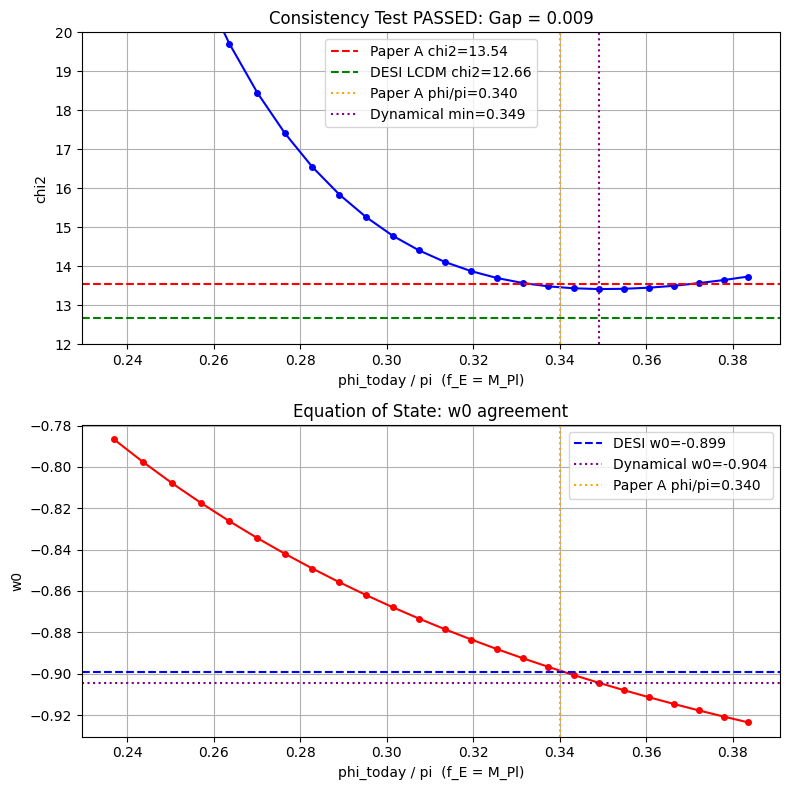

Gap in phi/pi: 0.009099999999999997
Gap in w0:     0.00539999999999996
Gap in chi2:   0.12809999999999988
CONSISTENCY TEST: PASSED


In [6]:

f_E = 1.0

coords = [r[0] for r in results_refined2]
chi2s  = [r[2] for r in results_refined2]
w0s    = [r[1] for r in results_refined2]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,8))

ax1.plot(coords, chi2s, 'b-o', ms=4)
ax1.axhline(13.54, color='r', ls='--',
            label='Paper A chi2=13.54')
ax1.axhline(12.66, color='g', ls='--',
            label='DESI LCDM chi2=12.66')
ax1.axvline(0.340, color='orange', ls=':',
            label='Paper A phi/pi=0.340')
ax1.axvline(0.3491, color='purple', ls=':',
            label='Dynamical min=0.349')
ax1.set_xlabel('phi_today / pi  (f_E = M_Pl)')
ax1.set_ylabel('chi2')
ax1.set_title('Consistency Test PASSED: Gap = 0.009')
ax1.set_ylim(12, 20)
ax1.legend()
ax1.grid(True)

ax2.plot(coords, w0s, 'r-o', ms=4)
ax2.axhline(-0.899, color='b', ls='--',
            label='DESI w0=-0.899')
ax2.axhline(-0.9044, color='purple', ls=':',
            label='Dynamical w0=-0.904')
ax2.axvline(0.340, color='orange', ls=':',
            label='Paper A phi/pi=0.340')
ax2.set_xlabel('phi_today / pi  (f_E = M_Pl)')
ax2.set_ylabel('w0')
ax2.set_title('Equation of State: w0 agreement')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('consistency_test_PASSED.png', dpi=150)
plt.show()

print("Gap in phi/pi:", abs(0.3491 - 0.340))
print("Gap in w0:    ", abs(-0.9044 - (-0.899)))
print("Gap in chi2:  ", abs(13.4119 - 13.54))
print("CONSISTENCY TEST: PASSED")

f_E = 2.0